<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/%5BAA1%5DTP5_clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 AA1 Clasificación

Fernando Javier García Liévano.

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:


El dataset seleccionado es [Spambase](https://archive.ics.uci.edu/dataset/94/spambase) debido a que contiene más de 4 variables, no fue elegido por otra persona y es un caso de uso común e interesante para aplicar el concepto de **Clasificación**.

### Obtención del dataset

In [2]:
!pip install ucimlrepo

In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# spambase = id 94
dataset = fetch_ucirepo(id=94)
# convertir a dataframe de pandas
df = dataset.data.original.copy()

df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1



## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - Describan si observan o no relaciones entre algunas variables.  


## Resolución:

El dataset Spambase contiene información sobre emails marcados como spam o no spam y contiene 4601 registros con 57 características que representan varios atributos de emails como la frecuencia de ciertas palabras o caracteres.

### Inspección del Dataset

In [4]:
print(f'Cantidad de filas: {df.shape[0]} \n')
print(f'Cantidad de columnas: {df.shape[1]}\n ')

Cantidad de filas: 4601 

Cantidad de columnas: 58
 


In [5]:
tipos_variables = pd.DataFrame({
    'tipo': df.dtypes,
    'valores_unicos': df.nunique(),
    'nulos': df.isnull().sum()
})

tipos_variables

,tipo,valores_unicos,nulos
word_freq_make,float64,142,0
word_freq_address,float64,171,0
word_freq_all,float64,214,0
word_freq_3d,float64,43,0
word_freq_our,float64,255,0
word_freq_over,float64,141,0
word_freq_remove,float64,173,0
word_freq_internet,float64,170,0
word_freq_order,float64,144,0
word_freq_mail,float64,245,0


In [6]:
variables_numericas = df.select_dtypes(include='number').columns.tolist()
variables_categoricas = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(f'Variables numéricas({len(variables_numericas)}): {variables_numericas}')
print(f'Variables categóricas({len(variables_categoricas)}): {variables_categoricas}')

Variables numéricas(58): ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!', 'char_freq_$

### Descripción de Variables

In [7]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.10,0.31,0.0,0.00,0.00,0.00,4.54
word_freq_address,4601.0,0.21,1.29,0.0,0.00,0.00,0.00,14.28
word_freq_all,4601.0,0.28,0.50,0.0,0.00,0.00,0.42,5.10
word_freq_3d,4601.0,0.07,1.40,0.0,0.00,0.00,0.00,42.81
word_freq_our,4601.0,0.31,0.67,0.0,0.00,0.00,0.38,10.00
word_freq_over,4601.0,0.10,0.27,0.0,0.00,0.00,0.00,5.88
word_freq_remove,4601.0,0.11,0.39,0.0,0.00,0.00,0.00,7.27
word_freq_internet,4601.0,0.11,0.40,0.0,0.00,0.00,0.00,11.11
word_freq_order,4601.0,0.09,0.28,0.0,0.00,0.00,0.00,5.26
word_freq_mail,4601.0,0.24,0.64,0.0,0.00,0.00,0.16,18.18


> Las variables de frecuencia presentan en su mayoría valores bajos y concentraciones altas en 0, indicando que hay muchas palabras o caracteres que no aparecen en la mayoría de emails. También se nota que algunos valores máximos son muy superiores a la media lo que puede sugerir posible presencia de outliers.


### Distribución de variables

Se decidió estudiar variables consideradas importantes, como la frecuencia de algunas palabras como "free", "you", la frecuencia del símbolo "!" y el uso de mayúsculas.

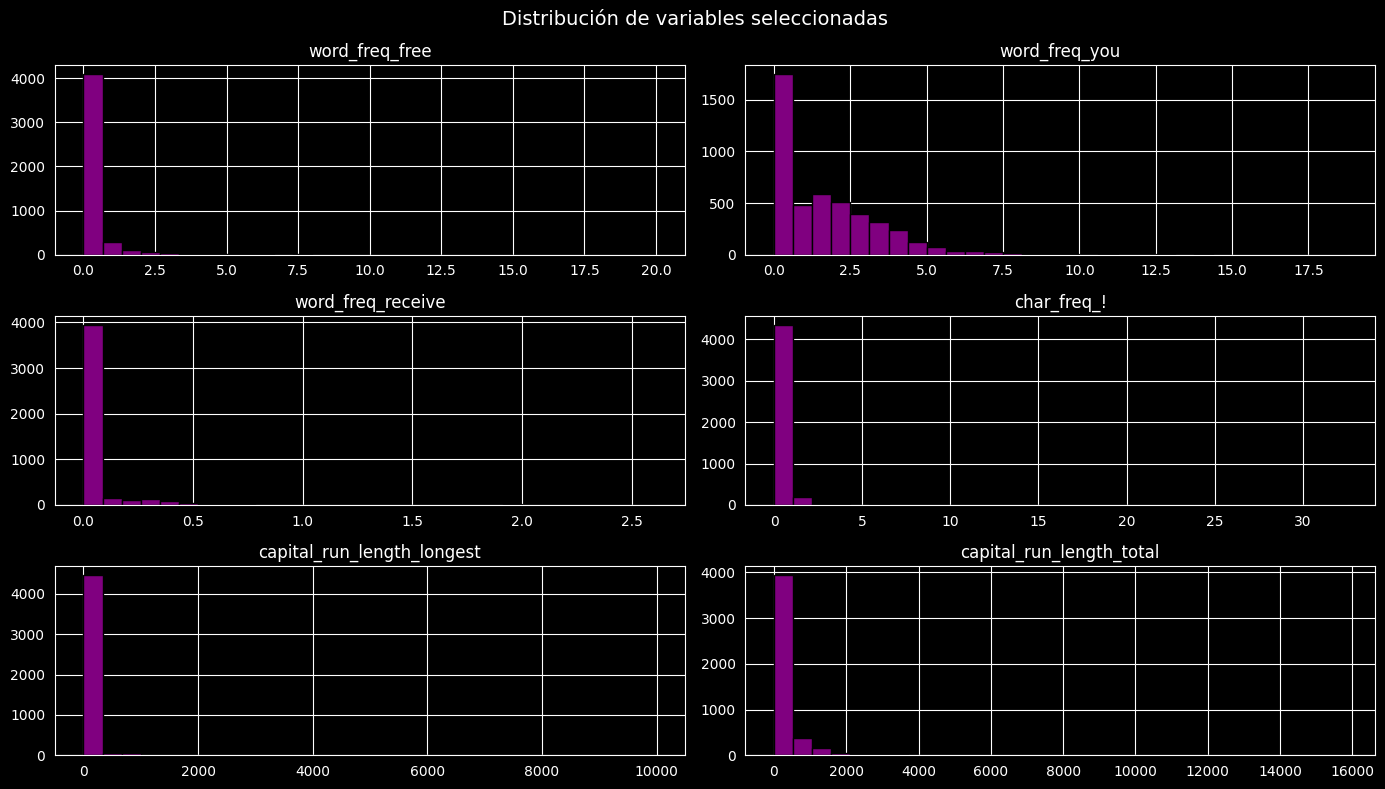

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# THEMING
sns.set_style("dark")
plt.style.use("dark_background")

features_seleccionadas = [
    'word_freq_free',
    'word_freq_you',
    'word_freq_receive',
    'char_freq_!',
    'capital_run_length_longest',
    'capital_run_length_total'
]

df[features_seleccionadas].hist(
    bins=30,
    figsize=(14, 8),
    color='purple',
    edgecolor='black'
)


plt.suptitle('Distribución de variables seleccionadas', fontsize=14)
plt.tight_layout()
plt.show()

> Las variables estudiadas muestran distribuciones muy sesgadas hacia la derecha, la mayoría de los correos no contienen las palabras *free* o *you*, signos de exclamación u oraciones largas en mayúsculas pero sí encontramos algunos casos con valores altos.


### Distribución de variables según Class

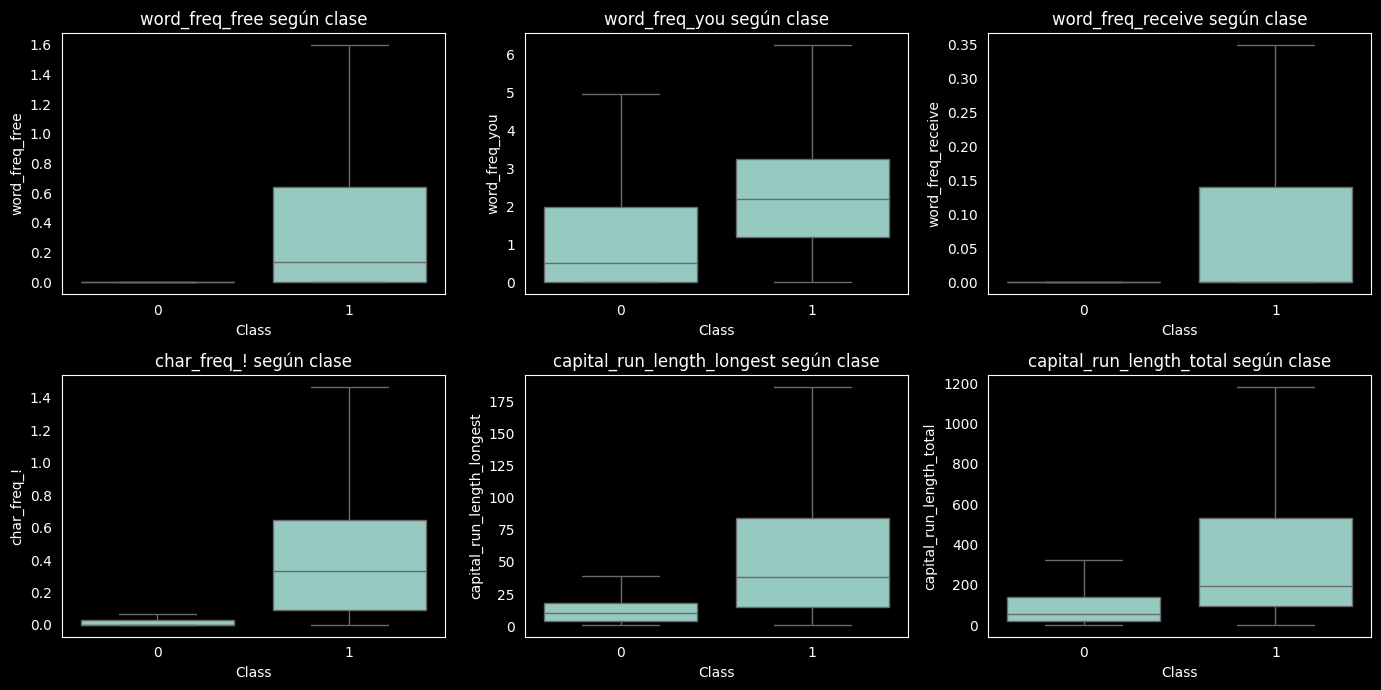

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, columna in zip(axes, features_seleccionadas):
    sns.boxplot(
        data=df,
        x='Class',
        y=columna,
        ax=ax,
        showfliers=False
    )

    ax.set_title(f'{columna} según clase')

plt.tight_layout()
plt.show()

> Se observa que los correos de la clase 1 (marcados como spam) presentan valores más altos y mayor dispersión en las variables analizadas, notandose especialmente en la frecuencia de *free*, *receive* y *!*.
>
> A pesar del solapamiento de clases visto en el boxplot correspondiente a la frecuencia de la palabra *you* y a los del uso de las mayúsculas, podemos inferir que las características seleccionadas pueden ser útiles para distinguir entre correos spam y no spam.


### Relación entre variables

Buscamos las variables que tengan mayor relación linean con `Class`

In [10]:
correlacion_target = (
    df.corr(numeric_only=True)['Class']
      .drop('Class')
      .sort_values(key=abs, ascending=False)
)

correlacion_target.head(10).round(3)

,Class
word_freq_your,0.383
word_freq_000,0.335
word_freq_remove,0.332
char_freq_$,0.324
word_freq_you,0.274
word_freq_free,0.263
word_freq_business,0.263
word_freq_hp,-0.257
capital_run_length_total,0.249
word_freq_our,0.242


Se seleccionaron las cuatro primeras características de la matriz de correlación.

In [11]:
top_features = correlacion_target.head(4).index.tolist()
top_features

['word_freq_your', 'word_freq_000', 'word_freq_remove', 'char_freq_$']

Gráfico:

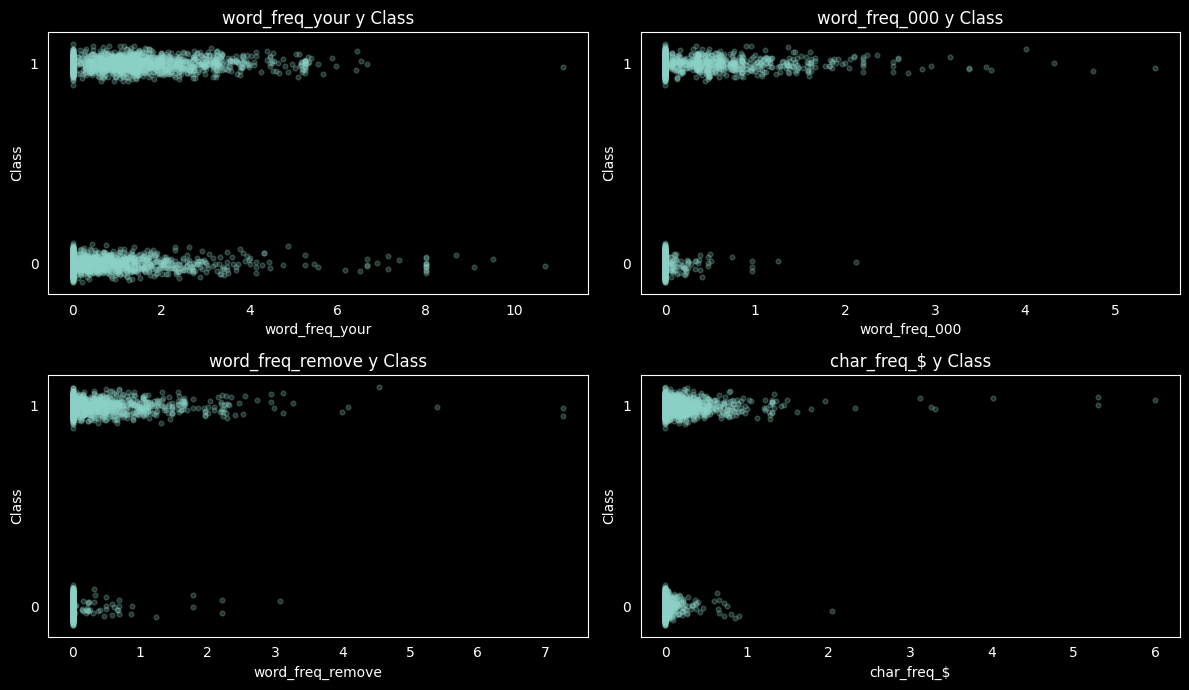

In [12]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

rng = np.random.default_rng(42)
class_jitter = df['Class'] + rng.normal(0, 0.03, size=len(df))

for ax, columna in zip(axes, top_features):
    ax.scatter(
        df[columna],
        class_jitter,
        alpha=0.25,
        s=12
    )

    ax.set_title(f'{columna} y Class')
    ax.set_xlabel(columna)
    ax.set_ylabel('Class')
    ax.set_yticks([0, 1])

plt.tight_layout()
plt.show()

> Mediante los scatterplots se observa que las palabras *000*, *remove* y el símbolo *$* presentan una asociación visible con la variable objetivo Class: los valores distintos a 0 y las frecuencias más altas aparecen en los correos de clase 1 (spam), mientras que en la clase 0 (no spam) estas variables se concentran mayormente alrededor de 0, lo que facilita el poder diferenciar los correos spam de no spam.

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

## Resolución:

### Características del Dataset

> El dataset cuenta con 4601 observaciones (correos), posee 57 variables predictoras que representan frecuencia de uso de palabras, símbolos o mayúsculas y una variable objetivo (Class) que indica si el correo es marcado como spam o no.
>
> Todas las variables predictoras son numéricas y la variable objetivo Class es binaria, lo que indica un problema de clasificación binaria.
>
> La clase 1 representa aproximadamente el 39% de los registros, sugiriendo un desbalance moderado pero no extremo.


### Limpieza de datos

Valores nulos

In [13]:
nulos = df.isnull().sum()
print("Columnas con valores nulos:", nulos[nulos > 0].index.tolist())


Columnas con valores nulos: []


> El dataset no contiene valores nulos, por lo que no será necesario tratar valores faltantes.

Valores duplicados

In [14]:
duplicados = df.duplicated().sum()
print("Cantidad de filas duplicadas:", duplicados)

print('Inspección de filas duplicadas')
duplicados = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
duplicados.sample(5)


Cantidad de filas duplicadas: 391
Inspección de filas duplicadas


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
3607,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,...,0.000,0.000,0.0,0.000,0.00,0.0,1.000,1,3,0
1361,0.09,0.49,0.59,0.0,0.29,0.19,0.0,0.0,0.09,0.39,...,0.766,0.037,0.0,5.836,1.31,0.0,5.792,54,753,1
3078,0.00,14.28,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,...,0.000,0.000,0.0,0.000,0.00,0.0,1.800,5,9,0
1113,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,...,0.000,0.000,0.0,1.326,0.00,0.0,2.200,11,44,1
2440,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.00,...,0.000,0.000,0.0,0.000,0.00,0.0,1.000,1,5,0


In [15]:
print('Verificación de duplicados')
df[df.duplicated(keep=False)].equals(df[df.duplicated(keep=False)].round(6))

Verificación de duplicados


True

Eliminamos duplicados para que el modelo no se sesgue con patrones repetidos

In [16]:
df_clean = df.drop_duplicates()

print(f'El dataset luego de eliminar duplicados, posee {df_clean.shape[0]} registros únicos')

El dataset luego de eliminar duplicados, posee 4210 registros únicos


### Variables descartadas y categóricas

Para el dataset Spambase se decidió no descartar ninguna feature ya que cada una representa una característica potencialmente relevante del contenido del correo. No se identificaron columnas irrelevandos, identificadores únicos o columnas duplicadas que justifiquen su eliminación.

Además, no hace falta codificación ya que todas las variables predictoras son numéricas y la variable objetivo también está representada de forma binaria.

### Tratamiento de Outliers

En este dataset los outliers en las frecuencias de palabras y caracteres son inherentes al spam y no errores en si. Son cruciales para la clasificación ya que eliminarlos resultaría en la pérdida de información clave que diferencia el spam del no-spam. Mantenerlos permite que el modelo aprenda estos patrones distintivos y su impacto puede ser manejado con técnicas adecuadas o por la robustez de ciertos modelos.

### División de los Datos

Se separan las variables predictoras de la variable objetivo Class. Luego se dividió el dataset en un conjunto de entrenamiento del 80% y un conjunto de prueba del 20%

In [17]:
from sklearn.model_selection import train_test_split

# separación de features y target
X = df.drop(columns='Class')
y = df['Class']

# división entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Registros de entrenamiento: {X_train.shape[0]}')
print(f'Registros de prueba: {X_test.shape[0]}')
print(f'Cantidad de features: {X_train.shape[1]}')

Registros de entrenamiento: 3680
Registros de prueba: 921
Cantidad de features: 57


### Escalado de variables


Las variables se encuentran en escalas diferentes, algunas representan frecuencias con valores bajos mientras que las variables relacionadas con el uso de mayúsculas alcanzan a tener valores más altos respecto a las demás.

Por este motivo se aplicó RobustScaler, ya que utiliza la mediana e IQR resulta menos sensible a outliers. El escalador se ajustó únicamente con el conjunto de entrenamiento para evitar fuga de información.

In [18]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# ajustamos únicamente los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# y enn test solo se aplica la transformación aprendida
X_test_scaled = scaler.transform(X_test)

# convertimos el resultado (arreglo numpy) en dataframe con pandas
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head().round(2)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
2940,0.05,0.00,1.12,0.0,0.38,0.1,0.00,0.00,0.55,0.00,...,0.0,0.2,0.68,0.05,0.00,0.27,0.00,0.28,0.81,4.32
1303,0.17,0.26,3.02,0.0,1.10,0.6,0.43,0.26,0.69,3.25,...,0.0,0.0,0.22,0.00,0.85,4.76,0.01,1.94,15.35,5.62
3468,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,...,0.0,0.0,-0.35,0.00,0.48,0.00,0.00,-0.16,-0.22,-0.16
3181,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,...,0.0,0.0,-0.35,0.00,0.00,0.00,0.00,0.97,0.14,-0.30
794,0.00,0.56,0.00,0.0,1.44,0.0,0.00,0.00,1.01,3.50,...,0.0,0.0,0.63,0.00,0.17,1.10,0.00,-0.06,1.03,1.92


El dataset contiene 4601 registros, 57 variables predictoras numéricas y una variable objetivo binaria, por lo que corresponde a un problema de clasificación binaria. No se encontraron valores faltantes ni variables categóricas que requirieran imputación o codificación.

Los valores extremos se conservaron, ya que pueden representar características reales y relevantes para la identificación de correos spam. No se descartaron variables inicialmente porque todas describen propiedades del contenido de los correos. Finalmente, los datos se dividieron de forma estratificada en conjuntos de entrenamiento y prueba, y se generaron versiones escaladas utilizando RobustScaler para los modelos sensibles a las diferencias de escala.




## 4. **Clasificación con logistic regression**  
   

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

### 4.1 Entrenamiento y evaluación

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

modelLR = LogisticRegression(max_iter=1000)

modelLR.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### 4.2 Métricas de evaluación

Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.

In [20]:
# Predicciones sobre entrenamiento y testeo
y_train_pred = modelLR.predict(X_train_scaled)
y_test_pred = modelLR.predict(X_test_scaled)

# Accuracy
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print("Desempeño en entrenamiento")
print(f"Accuracy: {accuracy_train:.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_train, y_train_pred))

print("\nInforme de clasificación:")
print(classification_report(y_train, y_train_pred))

print("\n" + "=" * 50)

print("Desempeño en testeo")
print(f"Accuracy: {accuracy_test:.4f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_test_pred))

print("\nInforme de clasificación:")
print(classification_report(y_test, y_test_pred))

Desempeño en entrenamiento
Accuracy: 0.9329

Matriz de confusión:
[[2137   93]
 [ 154 1296]]

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2230
           1       0.93      0.89      0.91      1450

    accuracy                           0.93      3680
   macro avg       0.93      0.93      0.93      3680
weighted avg       0.93      0.93      0.93      3680


Desempeño en testeo
Accuracy: 0.9283

Matriz de confusión:
[[529  29]
 [ 37 326]]

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



>**Métricas**
>
> Las métricas utilizadas fueron accuracy, precision, recall y F1-score y se utilizó la matriz de confusión para observar la cantidad de predicciones correctas e incorrectas realizadas para cada clase

> **Resultados**
>
> En el conjunto de testeo el modelo obtuvo una accuracy de aproximadamente 0.9283 lo que equivale a un 92.83% de las observaciones. La matriz de observaciones confirmó que el modelo clasificó correctamente 529 observaciones de la clase 0 y 326 observaciones de la clase 1, mientras clasificó incorrectamente 29 casos de la clase 0 y 37 casos de la clase 1.
>
> Mientras en el conjunto de entrenamiento, el modelo obtuvo una accuracy de 0.9329 equivalente a un 93.29% de las observaciones. Entonces, la similitud entre los resultados de entrenamiento y testeo indica que el modelo generaliza adecuadamente y que no se requiere un sobreajuste.

## 5- **Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

### Justificación
Se eligió **SVM (Support Vector Machine)** con los parámetros por defecto ya que SVM es muy efectivo en espacios de alta dimensionalidad (como spambase que cuenta con 57 variables) y es robusto para problemas de clasificación binaria.

### 5.2 Entrenamiento del modelo.

In [21]:
from sklearn.svm import SVC

modelSVM = SVC()

# entrenamiento con datos escalados
modelSVM.fit(X_train_scaled, y_train)

SVC()

### 5.3 Evaluación del desempeño

In [22]:
# predicciones
y_test_pred_svm = modelSVM.predict(X_test_scaled)

# evaluación
print("Desempeño SVM en Testeo")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_svm):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_test_pred_svm))
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_test_pred_svm))

Desempeño SVM en Testeo
Accuracy: 0.9121

Matriz de Confusión:
[[525  33]
 [ 48 315]]

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       558
           1       0.91      0.87      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.90      0.91       921
weighted avg       0.91      0.91      0.91       921




### Conclusión
>
> El modelo SVM con parámetros por defecto obtuvo una accuracy de 0.9121, siendo ligeramente inferior a la Regresión Logística (0.9283). La matriz de confusión revela que el SVM tuvo mayor dificultad para detectar casos de spam, generando 48 falsos negativos frente a los 37 del modelo previo. Esto demuestra que, sin un ajuste de hiperparámetros, un modelo más complejo no garantiza necesariamente un mejor desempeño inicial para este dataset.
```

## 6  Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.

> Para el tuneo de hiperparámetros de SVM, se utilizó `GridSearchCV` para poder explorar diferentes valores del parámetro de regularización C y del coeficiente del kernel gamma. El objetivo es encontrar una combinación que mejore el recall de la clase 1 (spam) sin tener que sacrificar excesivamente la precisión general y poder superar el desempeño de la Regresión Logística obtenida anteriormente.

In [23]:
from sklearn.model_selection import GridSearchCV

# espacio de parámetros a explorar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# configuramos la búsqueda (5-fold cross validation)
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=5)

# ejecutamos la búsqueda con los datos escalados
grid.fit(X_train_scaled, y_train)

print(f'Mejores parámetros encontrados: {grid.best_params_}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros encontrados: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}


In [24]:
# evaluamos el mejor modelo encontrado por la búsqueda
grid_predictions = grid.predict(X_test_scaled)

print('Desempeño SVM Optimizado en Testeo')
print(f'Accuracy: {accuracy_score(y_test, grid_predictions):.4f}')
print('\nMatriz de Confusión:')
print(confusion_matrix(y_test, grid_predictions))
print('\nInforme de Clasificación:')
print(classification_report(y_test, grid_predictions))

Desempeño SVM Optimizado en Testeo
Accuracy: 0.9338

Matriz de Confusión:
[[531  27]
 [ 34 329]]

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       558
           1       0.92      0.91      0.92       363

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921



> La optimización mediante GridSearchCV permitió identificar que los parámetros `C: 100` y `gamma: 0.001` son los más adecuados para este dataset. Gracias a este ajuste la accuracy del SVM subió a 0.9338, superando finalmente el desempeño de la Regresión Logística (0.9283). Además se logró reducir significativamente los falsos negativos a solo 34, mejorando la capacidad del modelo para detectar correos spam de manera efectiva.


## 7- Conclusiones

Fundamente, justifique con sus palabras.


> A lo largo de este trabajo se abordó el problema de detección de spam utilizando el dataset Spambase.
>
>Tras un análisis exploratorio y un preprocesamiento con RobustScaler se compararon dos modelos: Regresión Logística y SVM. Si bien la Regresión Logística mostró un excelente desempeño inicial (92.83%), la optimización de SVM tuenando los hiperparámetros permitió alcanzar el mejor resultado (accuracy) del experimento (93.38%), lo demuestra que elegir el modelo correcto y un proceso de tuneo bien ejecutado es fundamental conseguir los mejores resultados posibles en problemas de clasificación binaria.

# Referencias

Mencione los recursos utilizados


### Prompts:
- [Consulta 'Forma más óptima para hacer fetch del dataset'](https://chatgpt.com/c/6a4805e0-33d4-83e9-af88-628cb6ae6814)
- [Refuerzo y buenas prácticas](https://chatgpt.com/c/6a4add0e-12a0-83e9-860e-83e9ecb998a6)

# BONUS 1

Si su dataset estaba relativamente balanceado, como bonus pruebe entrenar otro modelo clasificador diferente y comparar resultados con su clasificador elegido en 5) y el modelo elegido 6) luego del tuneo de hiperparámetros.



# BONUS 2

Si su dataset estaba desbalanceado, puebe utilizar alguna técnica para lidiar con el desbalance de clases durante el entrenamiento.

1) Ofrezca una comparativa de entrenar y evaluar modelos de Logistic regression con y sin class_weight='balanced' o el modelo SVC con y sin class_weight='balanced'

2) Pruebe entrenar KNN con y sin uso de SMOTE

( Ver apunte sobre Desbalance de clases de la cátedra )

